In [1]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
base_path = Path("/content/drive/MyDrive/Colab Notebooks/solvro_zad_2/titanic.csv") # change path here!

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [94]:
titanic_df = pd.read_csv(base_path, index_col='PassengerId')

## ***Obserwacje z 1 zadania***

Usunę nadmiarowe kolumny ***SibSp*** i ***Parch***, ponieważ mam kolumnę ***Family_size***. Także usunę kolumny Embarked_. . . , ponieważ nie widzę w nich dużego sensu. Dla kolumny ***Fare*** zastosuje skalowanie logaretmiczne, bo ma dużo outlierów.
            

In [95]:
titanic_df.drop(columns=['SibSp', 'Parch', 'Embarked_Q', 'Embarked_C', 'Embarked_S'], inplace=True)

In [96]:
titanic_df['Fare'] = np.log1p(titanic_df['Fare'])
titanic_df.head(10)

,Survived,Pclass,Sex,Age,Fare,Family_size,Age_group
PassengerId,,,,,,,
1,0,3,1,22.0,2.110213,2,1
2,1,1,0,38.0,4.280593,2,1
3,1,3,0,26.0,2.188856,1,1
4,1,1,0,35.0,3.990834,2,1
5,0,3,1,35.0,2.202765,1,1
6,0,3,1,41.0,2.246893,1,1
7,0,1,1,54.0,3.967694,1,1
8,0,3,1,2.0,3.094446,5,0
9,1,3,0,27.0,2.740840,3,1


## Przygotowania

In [97]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import GridSearchCV

In [98]:
from sklearn.model_selection import train_test_split

X = titanic_df.drop('Survived', axis=1)
y = titanic_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.8, shuffle=True, random_state=42)

In [99]:
def metryki(model, X_train, X_test, y_train, y_test):
    """
    Funkcja obliczająca i wyświetlająca metryki oceny dla podanego modelu.
    1 Trenuje model na zbiorze treningowym i generuje predykcje dla zbioru testowego
    2 Wyświetla pełny raport klasyfikacji oraz macierz błędu
    3 Przeprowadza 5-krotną walidację krzyżową na zbiorze treningowym
    4 Oblicza i wypisuje średnią oraz odchylenie standardowe dla:
       accuracy, precision, recall i f1-score.
    """

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    scoring = ['accuracy', 'precision', 'recall', 'f1']
    wyniki = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)
    for metryka in scoring:
        srednia = wyniki[f'test_{metryka}'].mean()
        odchylenie = wyniki[f'test_{metryka}'].std()
        print(f"{metryka} — średnia: {srednia:.3f}     odchylenie: {odchylenie:.3f}")

Dodałem metryki precision, recall i f1-score, ponieważ samo accuracy może być mylące.

In [100]:
def model_test(choice, X_train, X_test, y_train, y_test, cv=5):
    """
    Funkcja testująca modele na podstawie parametru 'choice':
    0 - Drzewo Decyzyjne
    1 - K-Najbliższych Sąsiadów (KNN)
    2 - XGBoost
    """

    if choice == 0:
        model_name = "Drzewo Decyzyjne"
        model = DecisionTreeClassifier(random_state=42)
        siatka = {
            'max_depth':         [2, 3, 5, 10, 15, 20, 25, None],
            'criterion':         ['gini', 'entropy'],
            'min_samples_leaf':  [1, 3, 5, 7],
        }

    elif choice == 1:
        model_name = "K-Najbliższych Sąsiadów (KNN)"
        model = KNeighborsClassifier()
        siatka = {
            'metric':      ['cosine', 'euclidean', 'manhattan'],
            'n_neighbors': [3, 5, 10, 15, 20, 25]
        }
    elif choice == 2:
        model_name = "XGBoost"
        model = XGBClassifier(random_state=42)
        siatka = {
            'max_depth':         [2, 3, 5, 10],
            'eta':         [0.05, 0.1, 0.2],
            'n_estimators':      [30, 50, 100, 150],
            'min_child_weight':  [1, 3, 5]
        }
    else:
        print("Błąd: Nieprawidłowy wybór. Podaj 0, lub 1.")
        return None

    print(f"model {model_name}")

    szukaj = GridSearchCV(
        estimator=model,
        param_grid=siatka,
        cv=cv,
        scoring='accuracy'
    )
    szukaj.fit(X_train, y_train)
    print("Najlepsze ustawienia: ", szukaj.best_params_)
    print("Wynik kroswalidacji:  ", round(szukaj.best_score_, 3))
    print("Wynik na teście:      ", round(szukaj.score(X_test, y_test), 3))

    tabela = pd.DataFrame(szukaj.cv_results_)
    parameter_columns = [f'param_{keys}' for keys in siatka.keys()]
    print_columns = parameter_columns + ['mean_test_score', 'std_test_score']
    tabela = tabela[print_columns]

    plt.figure(figsize=(10, 6))
    if choice == 0:
        sns.lineplot(data=tabela, x='param_max_depth', y='mean_test_score',
                     style='param_criterion', hue='param_min_samples_leaf')

    elif choice == 1:
        sns.lineplot(data=tabela, x='param_n_neighbors', y='mean_test_score',
                     hue='param_metric')

    elif choice == 2:
        sns.lineplot(data=tabela, x='param_n_estimators', y='mean_test_score',
                     hue='param_eta', style='param_max_depth',
                     errorbar=None, estimator='max')

    plt.title(f"Wpływ hiperparametrów na skuteczność: {model_name}")
    plt.ylabel("Średnia skuteczność (mean_test_score)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return tabela.sort_values('mean_test_score', ascending=False).head(10)

## ***Dummy Classifier***

In [101]:
model_dummy = DummyClassifier(strategy='uniform')
metryki(model_dummy, X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.62      0.50      0.55       105
           1       0.44      0.55      0.49        74

    accuracy                           0.53       179
   macro avg       0.53      0.53      0.52       179
weighted avg       0.54      0.53      0.53       179

[[53 52]
 [33 41]]
accuracy — średnia: 0.469     odchylenie: 0.035
precision — średnia: 0.354     odchylenie: 0.026
recall — średnia: 0.497     odchylenie: 0.049
f1 — średnia: 0.413     odchylenie: 0.031


## ***SVM***

In [102]:
model_SVM = SVC(kernel='linear')
metryki(model_SVM, X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       105
           1       0.75      0.70      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179

[[88 17]
 [22 52]]
accuracy — średnia: 0.788     odchylenie: 0.029
precision — średnia: 0.739     odchylenie: 0.042
recall — średnia: 0.675     odchylenie: 0.055
f1 — średnia: 0.705     odchylenie: 0.046


## ***Decision Tree***

model Drzewo Decyzyjne
Najlepsze ustawienia:  {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 7}
Wynik kroswalidacji:   0.813
Wynik na teście:       0.81


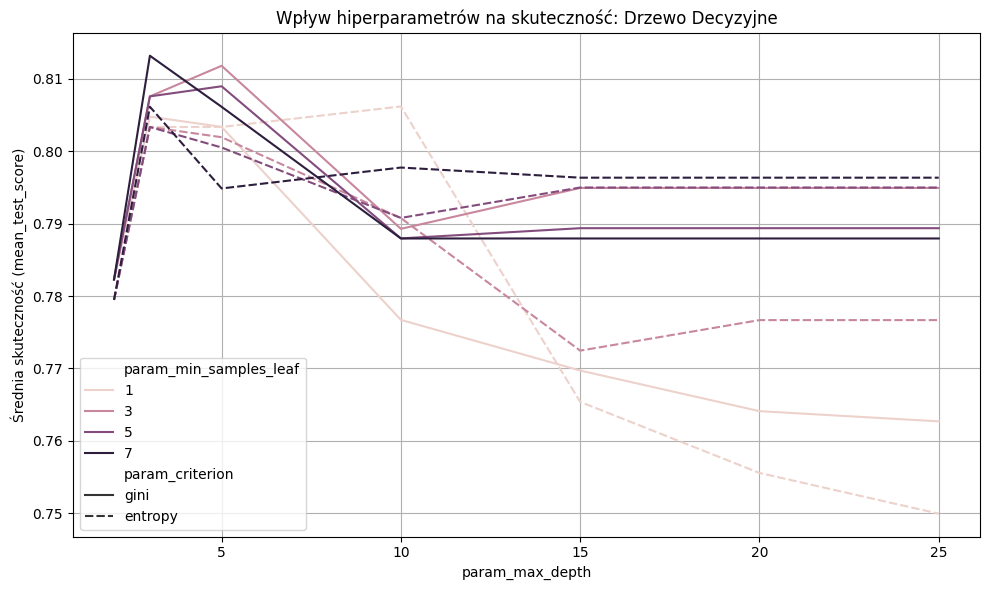

,param_max_depth,param_criterion,param_min_samples_leaf,mean_test_score,std_test_score
7,3,gini,7,0.813169,0.020975
9,5,gini,3,0.811780,0.011526
10,5,gini,5,0.808953,0.012593
5,3,gini,3,0.807554,0.022761
6,3,gini,5,0.807554,0.022761
44,10,entropy,1,0.806166,0.024328
39,3,entropy,7,0.806126,0.031027
11,5,gini,7,0.806116,0.019248
4,3,gini,1,0.804757,0.021231
8,5,gini,1,0.803349,0.009342


In [103]:
model_test(0, X_train, X_test, y_train, y_test)

Jak widać na wykresie im większa głebokość drzewa i mniejsza liczba próbek w liściu tym skuteczność modelu spada. Zwiększenie głębokości drzewa może doprowadzić do przeuczenia. Najlepszą kombinacją jest: max_depth = 3, min_samples_leaf = 7, criterion - gini.

In [104]:
model_decisionTree = DecisionTreeClassifier(max_depth=3, criterion='gini', min_samples_leaf=7)
metryki(model_decisionTree, X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

[[92 13]
 [21 53]]
accuracy — średnia: 0.813     odchylenie: 0.021
precision — średnia: 0.786     odchylenie: 0.021
recall — średnia: 0.690     odchylenie: 0.054
f1 — średnia: 0.734     odchylenie: 0.039


In [105]:
model_decisionTree = DecisionTreeClassifier(max_depth=5, criterion='gini', min_samples_leaf=3)
metryki(model_decisionTree, X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.70      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

[[92 13]
 [22 52]]
accuracy — średnia: 0.812     odchylenie: 0.012
precision — średnia: 0.789     odchylenie: 0.009
recall — średnia: 0.682     odchylenie: 0.052
f1 — średnia: 0.731     odchylenie: 0.028


## ***KNN***

model K-Najbliższych Sąsiadów (KNN)
Najlepsze ustawienia:  {'metric': 'cosine', 'n_neighbors': 3}
Wynik kroswalidacji:   0.795
Wynik na teście:       0.788


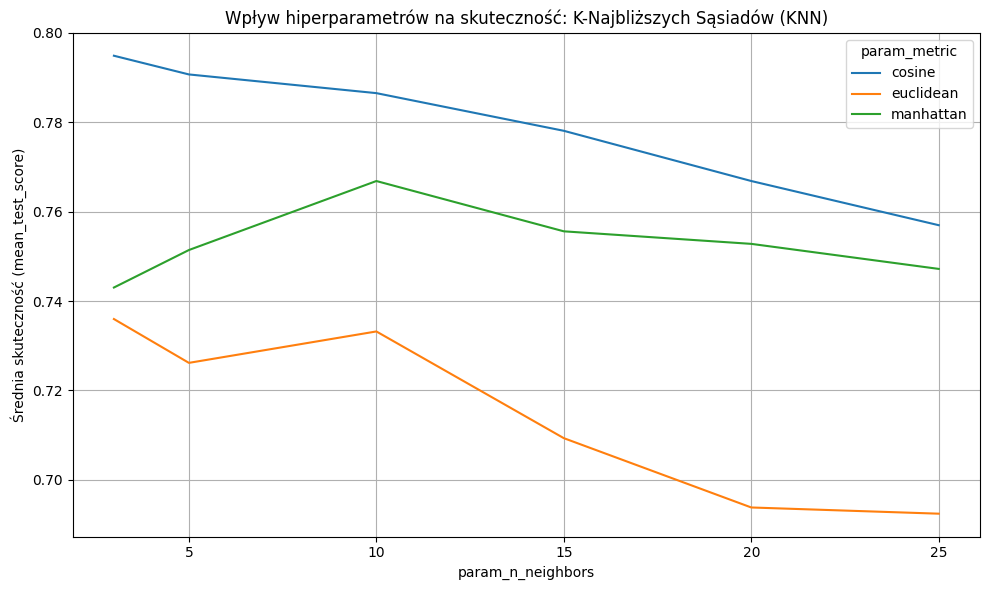

,param_metric,param_n_neighbors,mean_test_score,std_test_score
0,cosine,3,0.794908,0.020405
1,cosine,5,0.790722,0.016291
2,cosine,10,0.786536,0.020465
3,cosine,15,0.778105,0.022769
4,cosine,20,0.766867,0.020909
14,manhattan,10,0.766867,0.016689
5,cosine,25,0.756978,0.013787
15,manhattan,15,0.755609,0.025028
16,manhattan,20,0.752802,0.023768
13,manhattan,5,0.751423,0.010005


In [106]:
model_test(1, X_train, X_test, y_train, y_test)

Jak widać na wykresie, użyta miara odległości ma duże znaczenie – metryka cosine całkowicie zdominowała, wykazując się znacznie wyższą skutecznością niż pozostali dystanse. Skuteczność modelu spada wraz ze wzrostem liczby sąsiadów (n_neighbors). Zbyt duża liczba sąsiadów sprawia, że algorytm gubi granicę między ocalałymi a ofiarami (niedouczenie). Najlepszą kombinacją jest: metric = cosine, n_neighbors = 3.

In [107]:
model_KNN = KNeighborsClassifier(n_neighbors=3, metric='cosine')
metryki(model_KNN, X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.81      0.84      0.82       105
           1       0.76      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

[[88 17]
 [21 53]]
accuracy — średnia: 0.795     odchylenie: 0.020
precision — średnia: 0.742     odchylenie: 0.034
recall — średnia: 0.697     odchylenie: 0.030
f1 — średnia: 0.719     odchylenie: 0.029


In [108]:
model_KNN = KNeighborsClassifier(n_neighbors=5, metric='cosine')
metryki(model_KNN, X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       105
           1       0.81      0.68      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

[[93 12]
 [24 50]]
accuracy — średnia: 0.791     odchylenie: 0.016
precision — średnia: 0.751     odchylenie: 0.033
recall — średnia: 0.668     odchylenie: 0.036
f1 — średnia: 0.706     odchylenie: 0.022


## ***XGBoost***

model XGBoost
Najlepsze ustawienia:  {'eta': 0.1, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 100}
Wynik kroswalidacji:   0.843
Wynik na teście:       0.816


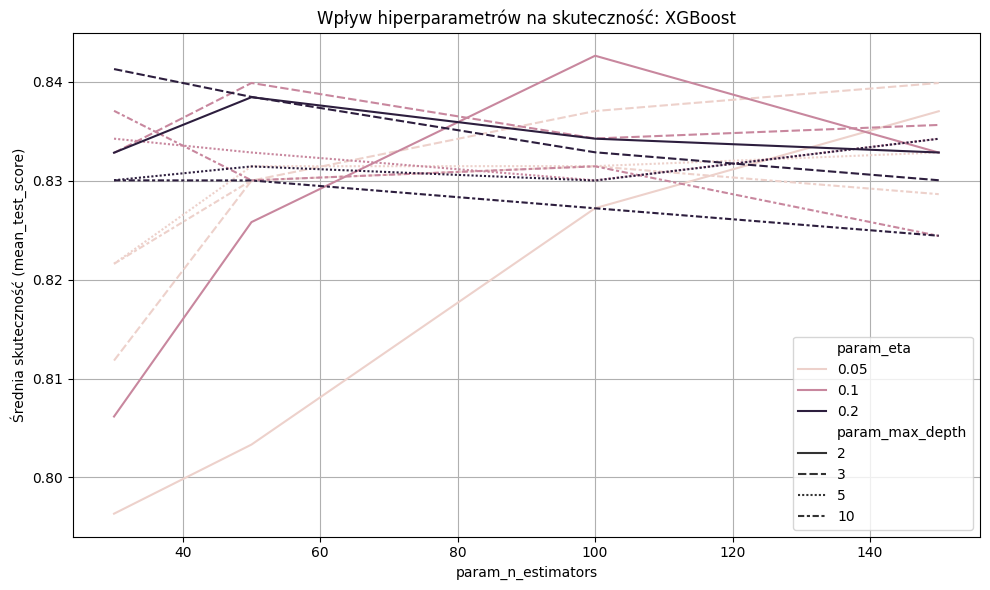

,param_max_depth,param_eta,param_n_estimators,param_min_child_weight,mean_test_score,std_test_score
58,2,0.10,100,5,0.842657,0.024860
112,3,0.20,30,3,0.841308,0.016253
15,3,0.05,150,1,0.839900,0.025656
69,3,0.10,50,5,0.839900,0.018447
19,3,0.05,150,3,0.838491,0.013977
109,3,0.20,50,1,0.838491,0.022202
116,3,0.20,30,5,0.838462,0.015634
105,2,0.20,50,5,0.838462,0.026843
92,10,0.10,30,5,0.837083,0.016252
22,3,0.05,100,5,0.837063,0.019225


In [109]:
model_test(2, X_train, X_test, y_train, y_test)

Jak widać najlepsze rezultaty osiągane są poprzez budowę wielu drzew. Parametry max_depth i min_child_weight mają taką samą zależność, jak i dla drzewa decyzyjnego. Najlepszą kombinacją jest: max_depth = 2, eta = 0.1, n_estimators = 100, min_child_weight = 5.

In [110]:
model_XGB = XGBClassifier(eta=0.1, max_depth=2, n_estimators=100, min_child_weight=5)
metryki(model_XGB, X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.84      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179

[[95 10]
 [23 51]]
accuracy — średnia: 0.843     odchylenie: 0.025
precision — średnia: 0.847     odchylenie: 0.058
recall — średnia: 0.716     odchylenie: 0.051
f1 — średnia: 0.774     odchylenie: 0.036


In [111]:
model_XGB = XGBClassifier(eta=0.2, max_depth=3, n_estimators=30, min_child_weight=3)
metryki(model_XGB, X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.66      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.80      0.80       179

[[95 10]
 [25 49]]
accuracy — średnia: 0.841     odchylenie: 0.016
precision — średnia: 0.855     odchylenie: 0.035
recall — średnia: 0.698     odchylenie: 0.037
f1 — średnia: 0.768     odchylenie: 0.027


## ***Wnioski***
*   Wszystkie przetestowane modele osiągnęły wyniki znacząco wyższe niż klasyfikator bazowy (Dummy Classifier).
*   Najlepszym modelem okazał się XGBoost, który osiągnął najwyższy wskaźnik f1_score = 75%. Blisko do tego wyniku okazał się Decision Tree mając 74%. Dalej jest KNN z wynikiem 71% oraz SVM 70%. Pod względem stabilności XGBoost też wypadł najlepiej mając najmniejsze odchylenie standardowe.
*   Modele KNN i SVM potrzebowali skalowania danych, tutaj nie wiem, czy wystarczyło przeskalowanie samego Fare.
*   Odnośnie badań hiperparametrów sprawdziłem modele na dwóch pierwszych kombinaciach, ponieważ ich różnicy w wynikach były nie wielkie, a różnica odchyleń była znacząca. Chciałem zobaczyć, czy przy drugiej kombinacji model byłby bardziej stabilny. Okazało się, że nie.